In [1]:
from sklearn.datasets import load_digits

from Split_Data.split_data import x_train

digits = load_digits()

In [3]:
digits.data.shape

(1797, 64)

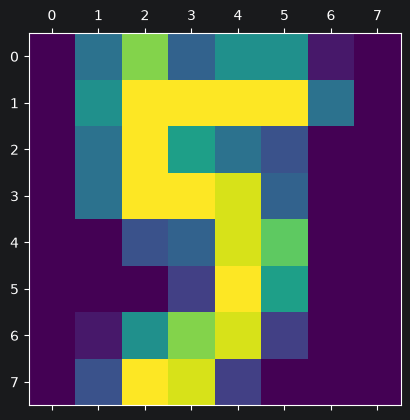

In [5]:
import matplotlib.pyplot as plt
plt.matshow(digits.images[33])
plt.show()

In [6]:
digits.target[33]

np.int64(5)

In [13]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [14]:
pca = PCA(n_components=3)
new_digits = pca.fit_transform(digits.data)

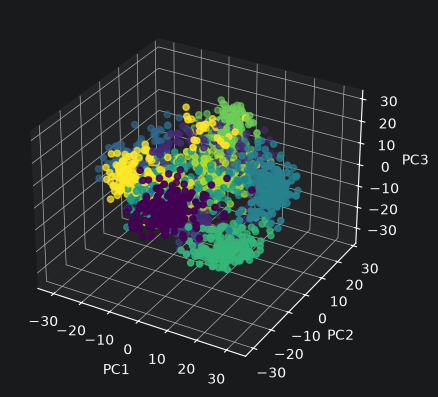

In [25]:
from matplotlib.pyplot import scatter

fig = plt.figure()
ax = fig.add_subplot(111,projection='3d')

ax.scatter(new_digits[:,0],new_digits[:,1],new_digits[:,2],c=digits.target)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

plt.show()


PCA for Speed up models

In [3]:
from sklearn.datasets import load_digits
import numpy as np

In [4]:
digits = load_digits()

In [5]:
digits.data.shape

(1797, 64)

In [6]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
new_data = sc.fit_transform(digits.data)

In [7]:
from sklearn.decomposition import PCA
pca = PCA(n_components=10)
new_data_pca = pca.fit_transform(new_data)

In [8]:
new_data_pca.shape

(1797, 10)

In [30]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(new_data, digits.target, test_size = 0.2, random_state = 42)

In [33]:
from sklearn.linear_model import LogisticRegression
import time

model = LogisticRegression(solver='lbfgs',max_iter=1000)
start = time.time()
model.fit(x_train, y_train)
end = time.time()

train_duration = end-start
print(train_duration*1000)

46.53739929199219


In [35]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)


0.9722222222222222


In [11]:
from sklearn.model_selection import train_test_split
x_train_pca, x_test_pca, y_train_pca, y_test_pca = train_test_split(new_data_pca, digits.target, test_size = 0.2, random_state = 42)

In [12]:
x_train_pca.shape

(1437, 10)

In [20]:
from sklearn.linear_model import LogisticRegression
import time

model = LogisticRegression(solver='lbfgs',max_iter=1000)
start = time.time()
model.fit(x_train_pca, y_train_pca)
end = time.time()

train_duration = end-start
print(train_duration*1000)

47.512054443359375


In [17]:
from sklearn.metrics import accuracy_score
y_pred_pca = model.predict(x_test_pca)
accuracy = accuracy_score(y_test_pca, y_pred_pca)
print(accuracy)


0.8972222222222223
